Import all the required libraries

In [222]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, roc_auc_score

Load the data

In [223]:
from pathlib import Path

data_path = Path('Telco_Customer_Churn.csv')
if not data_path.exists():
    raise FileNotFoundError('Telco_Customer_Churn.csv not found in project root.')

data = pd.read_csv(data_path)
print(f"\nSuccessfully loaded Customer Churn data. Shape: {data.shape}")


Successfully loaded Customer Churn data. Shape: (7043, 21)


In [224]:
type(data)

pandas.DataFrame

Data Cleaning

In [225]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Clean TotalCharges

In [226]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
original_rows = len(data)

data = data.dropna(subset=["TotalCharges"])
print(f"Cleaned Total Charges: Dropped {original_rows - len(data) } rows with NaNs.")

Cleaned Total Charges: Dropped 11 rows with NaNs.


In [227]:
data.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [228]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

Dependent and Target Features

In [229]:
target_feature = 'Churn'
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']

Combine all features for X and y

In [230]:
# X -> independent feature
# y -> dependent feature
X = data[numeric_features + categorical_features]
y = data[target_feature]

Target -> Churn

0 -> Not churn

1 -> Churn

Observation: Imbalanced Classification Problem

> Add blockquote



In [231]:
from collections import Counter
Counter(y)

Counter({'No': 5163, 'Yes': 1869})

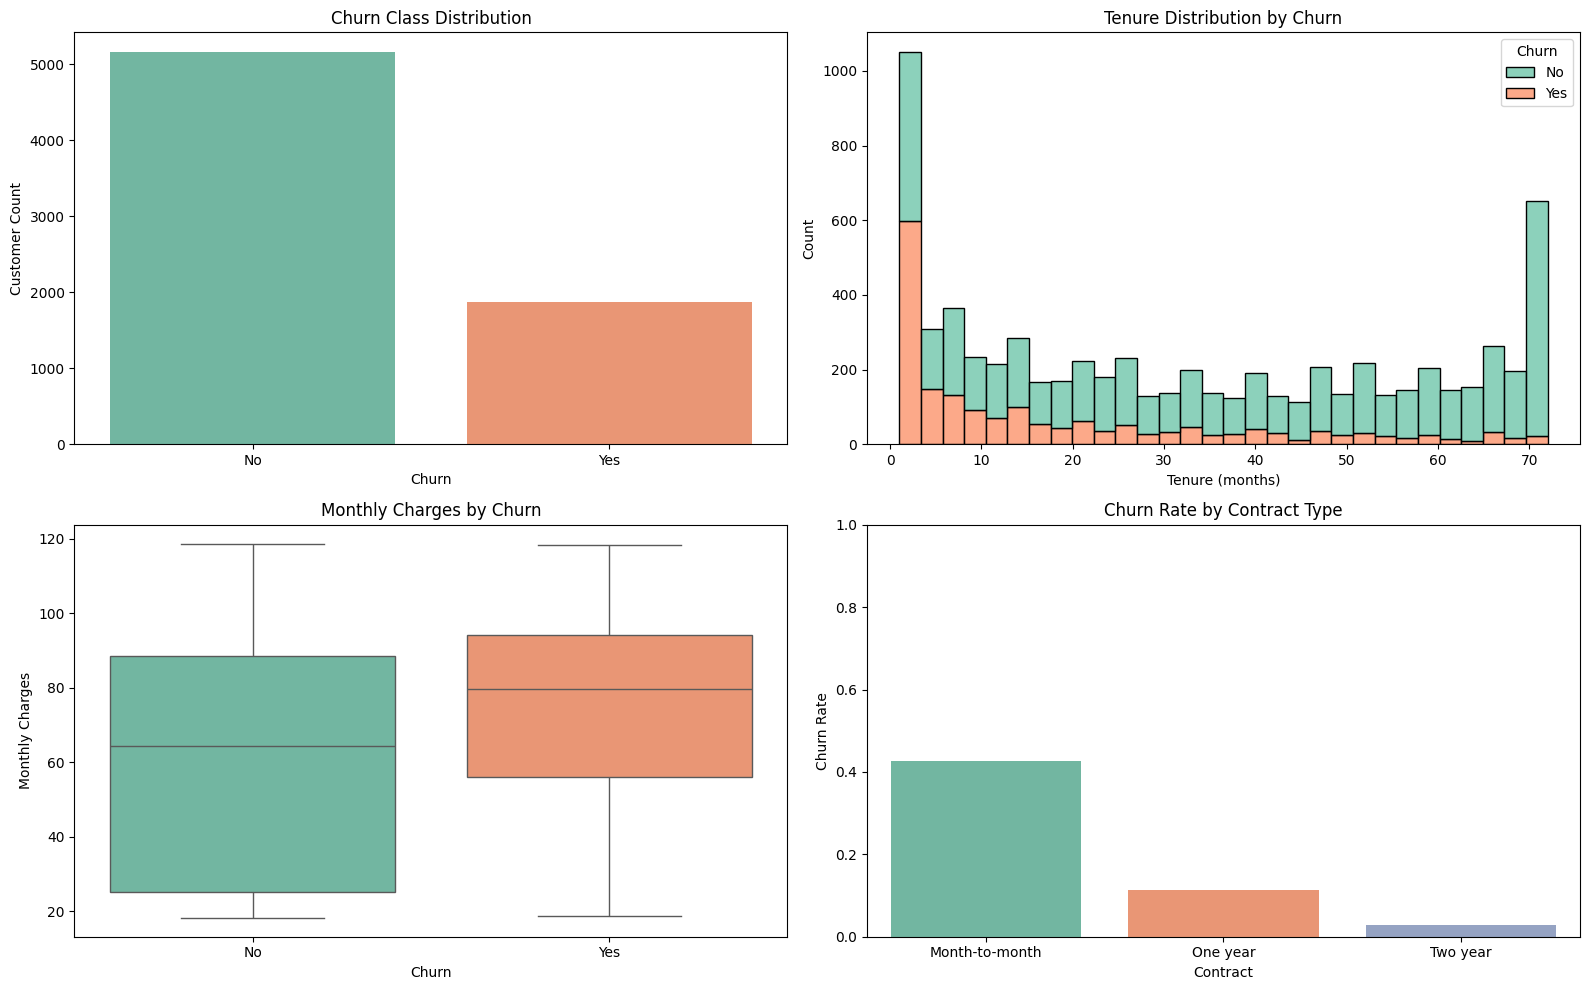

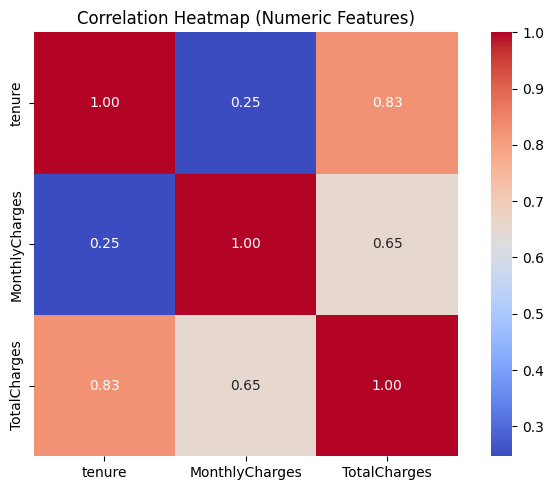

In [232]:
# Visual EDA dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Class distribution
sns.countplot(data=data, x='Churn', hue='Churn', palette='Set2', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Churn Class Distribution')
axes[0, 0].set_xlabel('Churn')
axes[0, 0].set_ylabel('Customer Count')

# 2) Tenure distribution by churn
sns.histplot(
    data=data, x='tenure', hue='Churn', bins=30, multiple='stack',
    palette='Set2', ax=axes[0, 1]
 )
axes[0, 1].set_title('Tenure Distribution by Churn')
axes[0, 1].set_xlabel('Tenure (months)')

# 3) Monthly charges by churn
sns.boxplot(data=data, x='Churn', y='MonthlyCharges', hue='Churn', palette='Set2', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Monthly Charges by Churn')
axes[1, 0].set_xlabel('Churn')
axes[1, 0].set_ylabel('Monthly Charges')

# 4) Churn rate by contract type
contract_churn_rate = (
    data.groupby('Contract', observed=False)['Churn']
    .apply(lambda s: (s == 'Yes').mean())
    .sort_values(ascending=False)
    .reset_index(name='ChurnRate')
)
sns.barplot(data=contract_churn_rate, x='Contract', y='ChurnRate', hue='Contract', palette='Set2', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Churn Rate by Contract Type')
axes[1, 1].set_xlabel('Contract')
axes[1, 1].set_ylabel('Churn Rate')
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Correlation heatmap for numeric features
plt.figure(figsize=(7, 5))
corr = data[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

Split the data into train and test set

In [233]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# stratify parameter ensures that the class imbalance is represented in both the sets [training and testing]

In [234]:
y_train = y_train.map({'Yes':1, 'No':0})
y_test = y_test.map({'Yes':1, 'No': 0})
y = y.map({'Yes':1, 'No': 0})

In [235]:
print(f"Original data churn rate: {y.mean():.4f}")
print(f"Training data churn rate: {y_train.mean():.4f}")
print(f"Testing data churn rate: {y_test.mean():.4f}")

Original data churn rate: 0.2658
Training data churn rate: 0.2657
Testing data churn rate: 0.2659


Full-Stack Pipeline

In [236]:
from sklearn.compose import ColumnTransformer

# --- 1. Numeric Preprocessing Batch
numeric_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


# --- 2. Categorical Preprocessing Batch
categorical_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


# --- 3. Combine the above batches with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder = 'drop'
)

# --- 4. Create the final, full-stack pipeline
clf_pipeline = Pipeline(steps =[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight = 'balanced',
        random_state = 42
    ))
])

Model Training on training set

In [237]:
clf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Model Prediction

In [238]:
y_predict = clf_pipeline.predict(X_test)
print(y_predict)

[0 1 0 ... 1 0 1]


In [239]:
y_prob = clf_pipeline.predict_proba(X_test)[:, 1]
print(y_prob)

[0.39717109 0.57209269 0.12870455 ... 0.74641361 0.03938791 0.76153802]


Model Evaluation

In [240]:
print(confusion_matrix(y_test, y_predict))

[[1110  439]
 [ 115  446]]


In [241]:
print(recall_score(y_test, y_predict))

0.7950089126559715


In [242]:
print(precision_score(y_test, y_predict))

0.503954802259887


ROC-AUC Curve

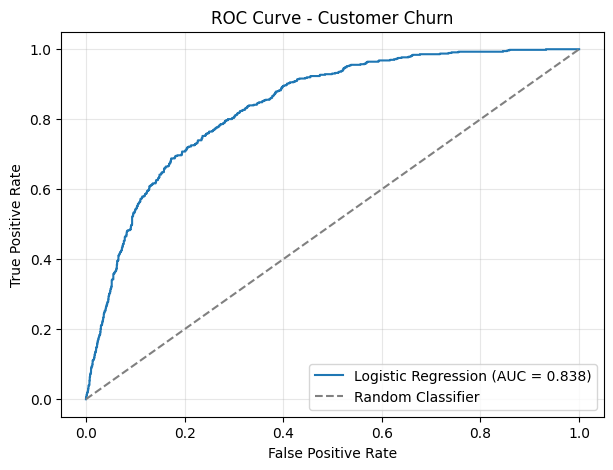

ROC-AUC Score: 0.8378


In [243]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Customer Churn')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f'ROC-AUC Score: {auc_score:.4f}')